In [1]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:02<00:00, 29.7MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [2]:
import zipfile

zip_path = "creditcardfraud.zip"   # your zip file name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()   # extracts in current directory

print("Unzipped successfully!")

Unzipped successfully!


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("creditcard.csv")

print(df.shape) #shape of the data
print(df.info()) #Info
print(df.isnull().sum()) #Null Count
print("Duplicates:", df.duplicated().sum()) #Duplicates check
print(df["Class"].value_counts()) #Class Count
print(df["Class"].value_counts(normalize=True) * 100) #Class Distribution

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

**Data is Highly Imbalance**

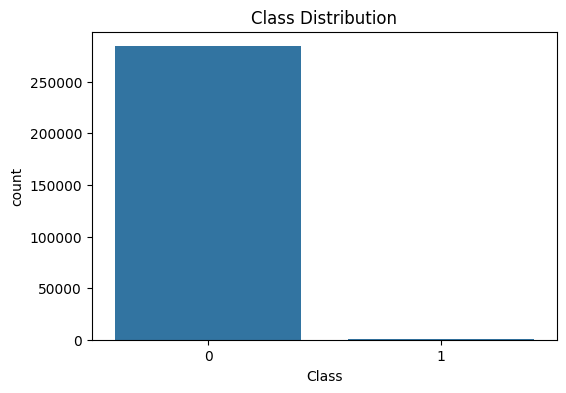

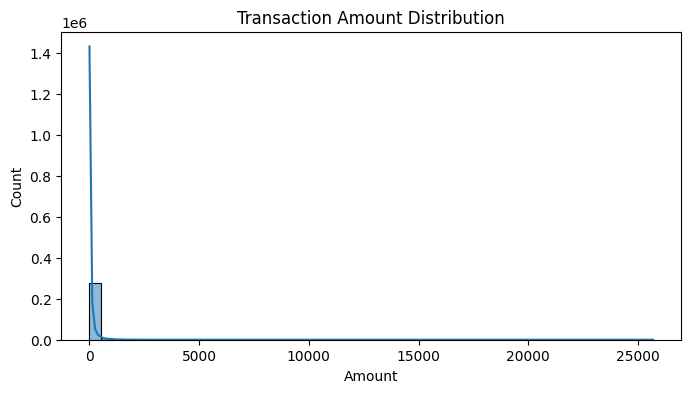

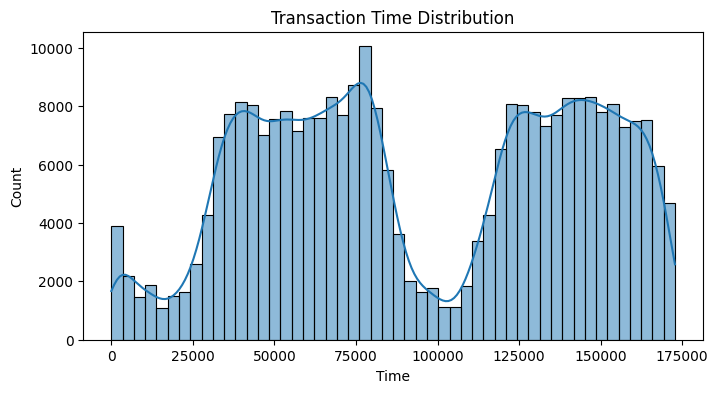

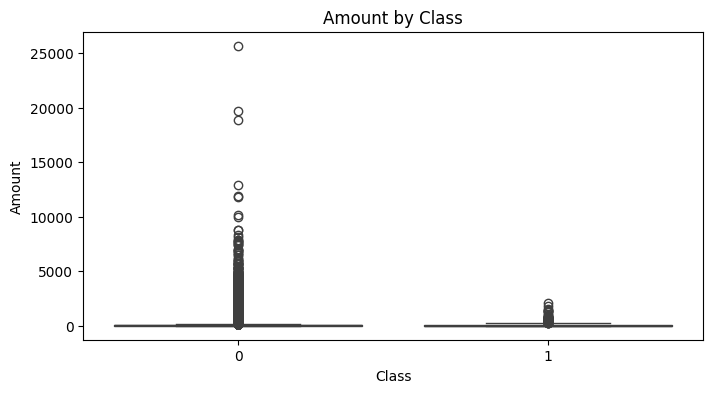

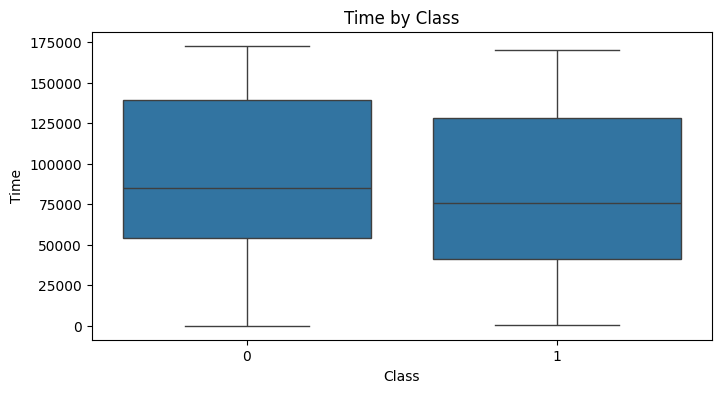

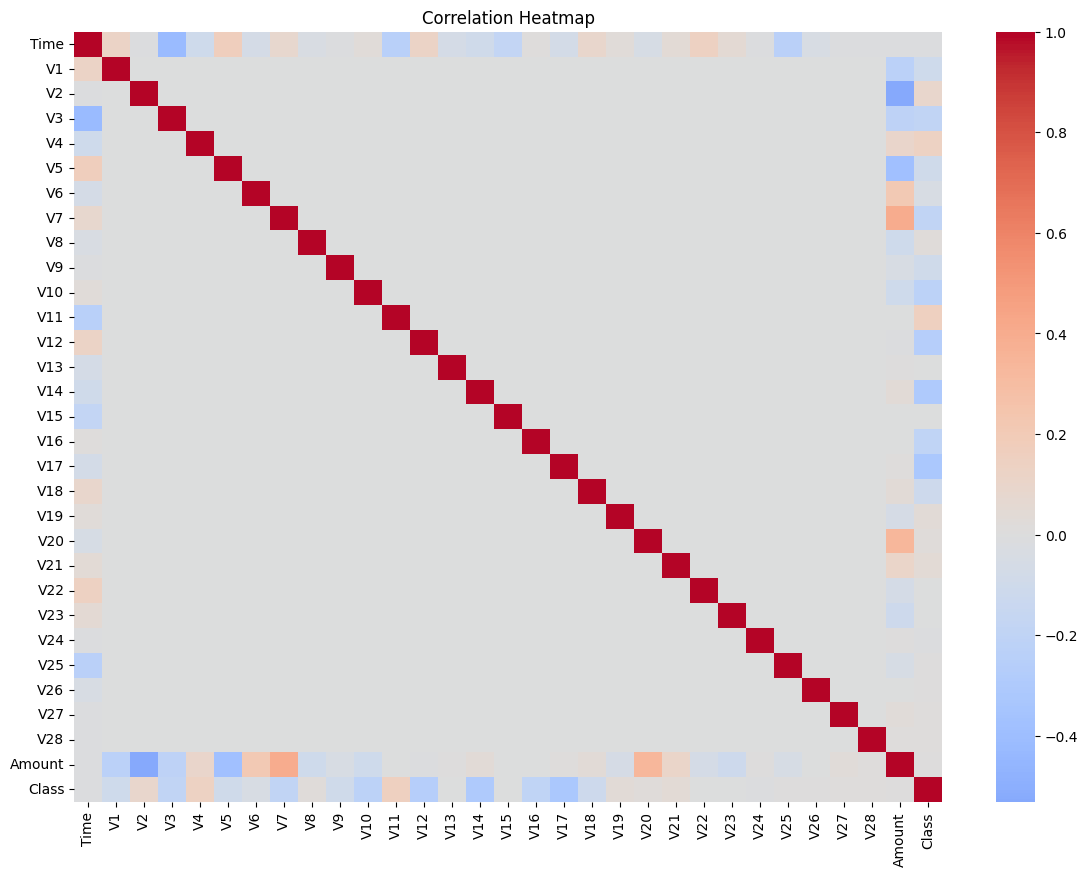

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df["Time"], bins=50, kde=True)
plt.title("Transaction Time Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by Class")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="Class", y="Time", data=df)
plt.title("Time by Class")
plt.show()

corr = df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

**Fraud class is extremely rare**

**Fraud transactions may show different amount/time behavior**

**Imbalance means accuracy alone is misleading**

**Precision, recall, F1, ROC-AUC are more important**

In [6]:
df = df.drop_duplicates().copy()

df["Hour"] = (df["Time"] // 3600) % 24
df["Amount_log"] = np.log1p(df["Amount"])

**Convert Time into hours**

**Normalize Amount**

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Split Data**


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

cols_to_scale = ["Amount", "Time", "Hour", "Amount_log"]

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

**Scale Data**

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

**Handle Data Imbalance**

In [11]:
threshold = df["Amount"].quantile(0.95)
df["High_Amount"] = (df["Amount"] > threshold).astype(int)

In [12]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=15)
X_train_sel = selector.fit_transform(X_train_smote, y_train_smote)
X_test_sel = selector.transform(X_test_scaled)

selected_features = X_train_scaled.columns[selector.get_support()]
print(selected_features)

Index(['V2', 'V3', 'V4', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17',
       'V21', 'Amount', 'Hour', 'Amount_log'],
      dtype='object')


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import numpy as np
import time

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=500,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=80,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)

    end = time.time()

    results.append({
        "Model": name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
        "ROC_AUC": roc_auc,
        "Time_sec": round(end - start, 2)
    })

    print(f"{name} done in {round(end - start, 2)} sec\n")

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print(results_df)

Training Logistic Regression...
Logistic Regression done in 5.8 sec

Training Random Forest...
Random Forest done in 165.84 sec

Training XGBoost...
XGBoost done in 7.37 sec

                 Model  Precision    Recall        F1   ROC_AUC  Time_sec
1        Random Forest   0.484663  0.831579  0.612403  0.979343    165.84
2              XGBoost   0.163968  0.852632  0.275042  0.979298      7.37
0  Logistic Regression   0.052498  0.873684  0.099045  0.964092      5.80


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

X_small = X_train_smote.sample(60000, random_state=42)
y_small = y_train_smote.loc[X_small.index]

param_grid = {
    "n_estimators": [50, 80, 100],
    "max_depth": [6, 8, 10],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4]
}

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=4,
    scoring="f1",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_small, y_small)

best_rf = random_search.best_estimator_
print("Best Params:", random_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}


In [19]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.54      0.83      0.65        95

    accuracy                           1.00     56746
   macro avg       0.77      0.92      0.83     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9807319794605753


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['Precision', 'Recall']
)

history = ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - Precision: 0.0297 - Recall: 0.7933 - loss: 0.3767 - val_Precision: 0.0528 - val_Recall: 0.8846 - val_loss: 0.1419
Epoch 2/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Precision: 0.0368 - Recall: 0.9000 - loss: 0.1795 - val_Precision: 0.0536 - val_Recall: 0.8974 - val_loss: 0.1090
Epoch 3/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Precision: 0.0361 - Recall: 0.9267 - loss: 0.1581 - val_Precision: 0.0676 - val_Recall: 0.8974 - val_loss: 0.0849
Epoch 4/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - Precision: 0.0427 - Recall: 0.9333 - loss: 0.1405 - val_Precision: 0.0604 - val_Recall: 0.9231 - val_loss: 0.0911
Epoch 5/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Precision: 0.0452 - Recall: 0.9367 - loss: 0.1236 - val_Precision: 0.0602 - val_Recall: 0.9231 - val_loss: 0.0975
Epoch 6/20
710/710 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Precision: 0.0484 - Recall: 0.9433 - loss: 0.1090 - val_Precision: 0.0795 - val_Recall: 0.9103 - val_loss:

In [21]:
y_prob_ann = ann.predict(X_test_scaled).ravel()
y_pred_ann = (y_prob_ann > 0.5).astype(int)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


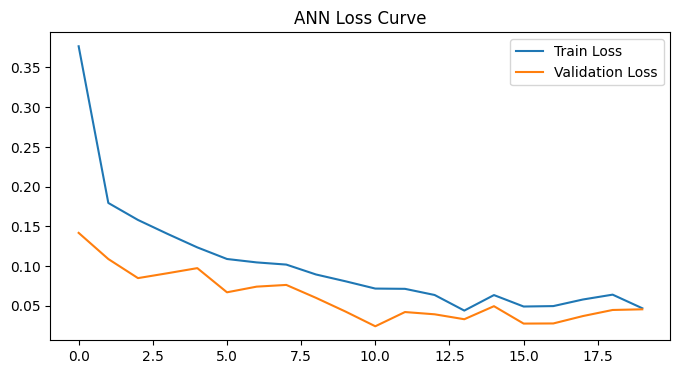

In [22]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("ANN Loss Curve")
plt.show()

In [23]:
import joblib

# save final model
joblib.dump(best_rf, "fraud_model.pkl")

# save scaler
joblib.dump(scaler, "scaler.pkl")

# save feature names
joblib.dump(list(X_train_scaled.columns), "feature_names.pkl")

# save scale columns
scale_cols = ["Amount", "Time", "Hour", "Amount_log"]
joblib.dump(scale_cols, "scale_cols.pkl")

print("All files saved successfully!")

All files saved successfully!


In [24]:
joblib.dump(selector, "selector.pkl")

['selector.pkl']